Loading processed_files/E1.mat...
Successfully extracted 4000 antenna readings.


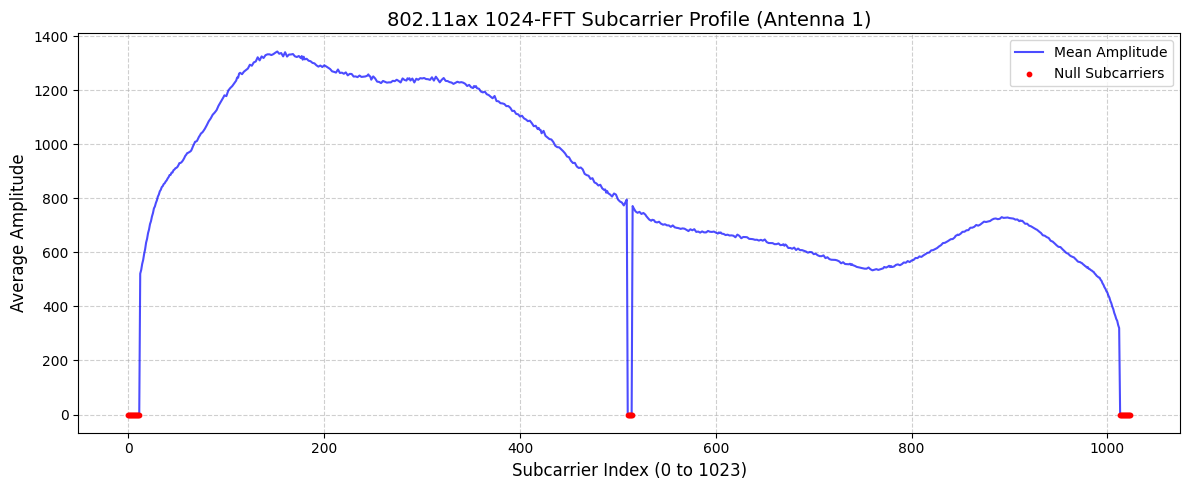

--- SUBCARRIER ANALYSIS ---
Total Subcarriers: 1024
Active Subcarriers Found: 996
Null Subcarriers Found: 28


In [1]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

def extract_complex_array(obj):
    """Recursively search for the 1024-length complex array in the MATLAB struct."""
    if isinstance(obj, np.ndarray):
        # Base case: we found the 1024-length array
        if obj.size == 1024:
            return obj.flatten()
        
        # If it's a structured array, check its fields (like 'nss' or 'data')
        if obj.dtype.names:
            for name in obj.dtype.names:
                res = extract_complex_array(obj[name])
                if res is not None:
                    return res
        # Otherwise, iterate through elements
        else:
            for item in obj.flat:
                res = extract_complex_array(item)
                if res is not None:
                    return res
    elif isinstance(obj, np.void): # Sometimes scipy loads structs as np.void
        for name in obj.dtype.names:
            res = extract_complex_array(obj[name])
            if res is not None: return res
    return None

def extract_single_file_subcarriers(file_path):
    print(f"Loading {file_path}...")
    mat = sio.loadmat(file_path)
    cores = mat['cores']
    num_packets = cores.shape[1]
    
    # We will just look at the first 1000 packets for the graph
    sample_packets = min(num_packets, 1000)
    
    # Pre-allocate: (Packets, Antennas, Subcarriers)
    csi_matrix = np.zeros((sample_packets, 4, 1024), dtype=np.complex128)
    
    success_count = 0
    for i in range(sample_packets):
        antennas = cores[0, i]
        for ant in range(4):
            try:
                # Use the recursive finder to bypass the nesting
                complex_data = extract_complex_array(antennas[0, ant])
                if complex_data is not None:
                    csi_matrix[i, ant, :] = complex_data
                    success_count += 1
                else:
                    print(f"Could not find 1024 array at packet {i}, antenna {ant}")
                    return None
            except Exception as e:
                print(f"Extraction error at packet {i}, antenna {ant}: {e}")
                return None

    print(f"Successfully extracted {success_count} antenna readings.")

    # 1. Calculate Amplitude: |H(f,t)|
    amplitude_matrix = np.abs(csi_matrix)
    
    # 2. Average the amplitude across time (packets) for Antenna 0
    mean_amplitude_ant0 = np.mean(amplitude_matrix[:, 0, :], axis=0)
    
    # 3. Identify Active Subcarriers (Thresholding above near-zero noise)
    active_indices = np.where(mean_amplitude_ant0 > 1e-4)[0]
    null_indices = np.where(mean_amplitude_ant0 <= 1e-4)[0]
    
    # --- Graph Analysis ---
    plt.figure(figsize=(12, 5))
    plt.plot(mean_amplitude_ant0, color='blue', alpha=0.7, label='Mean Amplitude')
    plt.scatter(null_indices, np.zeros_like(null_indices), color='red', s=10, label='Null Subcarriers', zorder=5)
    
    plt.title("802.11ax 1024-FFT Subcarrier Profile (Antenna 1)", fontsize=14)
    plt.xlabel("Subcarrier Index (0 to 1023)", fontsize=12)
    plt.ylabel("Average Amplitude", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print("--- SUBCARRIER ANALYSIS ---")
    print(f"Total Subcarriers: 1024")
    print(f"Active Subcarriers Found: {len(active_indices)}")
    print(f"Null Subcarriers Found: {len(null_indices)}")
    
    return active_indices

# Run the analysis
active_subcarriers = extract_single_file_subcarriers('processed_files/E1.mat')

In [21]:
def extract_first_level_features(file_path, active_indices, window_size=100, step_size=40):     
    print(f"Extracting features from {file_path}...")
    mat = sio.loadmat(file_path)
    cores = mat['cores']
    num_packets = cores.shape[1]
    
    # Pre-allocate temporary matrix with 4 antennas to keep ML input size constant
    csi_matrix = np.zeros((num_packets, 4, 1024), dtype=np.complex128)
    
    # 1. Extract the raw complex data dynamically
    for i in range(num_packets):
        antennas = cores[0, i]
        
        # Dynamically detect spatial streams (NSS), cap at 4
        num_streams = antennas.shape[1] if len(antennas.shape) > 1 else 1
        limit_streams = min(4, num_streams)
        
        for ant in range(limit_streams):
            try:
                complex_data = extract_complex_array(antennas[0, ant])
                if complex_data is not None:
                    csi_matrix[i, ant, :] = complex_data
            except Exception as e:
                # Silently skip malformed individual antenna packets
                continue
                
    # 2. Sanitize: Keep only active subcarriers and get amplitude
    # Shape becomes (Packets, Antennas, 996)
    clean_amplitude = np.abs(csi_matrix[:, :, active_indices])
    
    # 3. Spatial Aggregation: Average across subcarriers to get Effective Amplitude
    # Shape becomes (Packets, 4 Antennas)
    effective_amp = np.mean(clean_amplitude, axis=2)
    
    features = []
    
    # 4. The Sliding Window Logic (First-Level)
    for start_idx in range(0, num_packets - window_size + 1, step_size):
        # Extract the window: Shape (100, 4)
        window_data = effective_amp[start_idx : start_idx + window_size, :]
        
        window_features = []
        for ant in range(4):
            ant_data = window_data[:, ant]
            
            # Feature 1: Mean
            mu = np.mean(ant_data)
            
            # Feature 2: Standard Deviation (STD)
            sigma = np.std(ant_data)
            
            # Feature 3: Peak-to-Average Ratio (PAR)
            par = np.max(ant_data) / mu if mu > 0 else 0
            
            # Feature 4: Rician K-Factor (Moment-matching approximation)
            # K = (Mean^2) / Variance
            variance = np.var(ant_data)
            k_factor = (mu**2) / variance if variance > 0 else 0
            
            window_features.extend([mu, sigma, par, k_factor])
            
        features.append(window_features)
        
    feature_matrix = np.array(features)
    return feature_matrix

# Test it on the file that previously failed
sample_features = extract_first_level_features('processed_files/R1_P1.mat', active_subcarriers)

print("\n--- FEATURE EXTRACTION REPORT ---")
print(f"Total packets processed: {sio.loadmat('processed_files/R1_P1.mat')['cores'].shape[1]}")
print(f"Generated Feature Matrix Shape: {sample_features.shape} -> (Windows, Features)")
print(f"Features per window: {sample_features.shape[1]} (4 stats * 4 antennas)")
print(f"Sample Feature Vector (First window): \n{np.round(sample_features[0][:8], 4)} ...")

Extracting features from processed_files/R1_P1.mat...

--- FEATURE EXTRACTION REPORT ---
Total packets processed: 15755
Generated Feature Matrix Shape: (392, 16) -> (Windows, Features)
Features per window: 16 (4 stats * 4 antennas)
Sample Feature Vector (First window): 
[8.759063e+02 2.458380e+01 1.067800e+00 1.269452e+03 9.209380e+02
 8.858350e+01 1.152400e+00 1.080825e+02] ...


In [22]:
import numpy as np

def calc_lcr_afd(data):
    """Calculate Level Crossing Rate and Average Fade Duration."""
    # Dynamic threshold: the median of the short temporal window
    threshold = np.median(data)
    
    # Boolean array of when the signal is 'fading' (below threshold)
    is_below = data < threshold
    
    # LCR: Count how many times it changes state (crosses the threshold)
    crossings = np.count_nonzero(np.diff(is_below))
    
    if not np.any(is_below):
        return crossings, 0.0
        
    # AFD: Find durations of 'fades' (consecutive points below threshold)
    padded = np.insert(is_below, [0, len(is_below)], [False, False])
    diffs = np.diff(padded.astype(int))
    starts = np.where(diffs == 1)[0]
    ends = np.where(diffs == -1)[0]
    durations = ends - starts
    afd = np.mean(durations)
    
    return crossings, afd

def calc_nakagami(data):
    """Estimate Nakagami-m parameters (m and Omega) using moment matching."""
    z_sq = np.square(data)
    omega = np.mean(z_sq)
    var_z_sq = np.var(z_sq)
    
    # Avoid division by zero for perfectly flat signals (e.g., empty room)
    # The lowest theoretical value for m is 0.5 (one-sided Gaussian)
    m = (omega**2) / var_z_sq if var_z_sq > 1e-8 else 0.5 
    
    return m, omega

def extract_second_level_features(first_level_matrix, N_F=8):              
    print(f"Applying Second-Level Feature Window (N_F={N_F})...")
    num_windows, num_first_level_features = first_level_matrix.shape
    
    # We lose (N_F - 1) windows at the start due to the rolling window
    num_final_samples = num_windows - N_F + 1
    
    final_features = []
    
    for i in range(num_final_samples):
        # Extract the N_F sized window
        window = first_level_matrix[i : i + N_F, :]
        
        sample_features = []
        
        # For each of the 16 base features, calculate the second-level dynamics
        for f_idx in range(num_first_level_features):
            feature_series = window[:, f_idx]
            
            # 1. Base value (take the mean of the window to retain the base magnitude)
            base_mean = np.mean(feature_series)
            
            # 2. LCR & AFD
            lcr, afd = calc_lcr_afd(feature_series)
            
            # 3. Nakagami m and Omega
            m, omega = calc_nakagami(feature_series)
            
            # Append all 5 temporal stats for this specific feature
            sample_features.extend([base_mean, lcr, afd, m, omega])
            
        final_features.append(sample_features)
        
    return np.array(final_features)

# Test it on the first-level matrix we generated in Cell 2
final_feature_matrix = extract_second_level_features(sample_features, N_F=8)

print("\n--- PHASE 3: TEMPORAL DYNAMICS REPORT ---")
print(f"Input First-Level Shape: {sample_features.shape}")
print(f"Output Second-Level Shape: {final_feature_matrix.shape}")
print(f"Total Final Features per Sample: {final_feature_matrix.shape[1]}")

Applying Second-Level Feature Window (N_F=8)...

--- PHASE 3: TEMPORAL DYNAMICS REPORT ---
Input First-Level Shape: (392, 16)
Output Second-Level Shape: (385, 80)
Total Final Features per Sample: 80


# skip from here 

In [12]:
import os
import glob
import numpy as np

def build_master_dataset(directory_path, active_indices):
    print("🚀 Starting Master Pipeline...")
    
    # Find all .mat files in the directory
    mat_files = glob.glob(os.path.join(directory_path, '*.mat'))
    
    if not mat_files:
        print("Error: No .mat files found in the specified directory.")
        return None, None
        
    X_list = []
    y_list = []
    
    file_count = 0
    
    for file_path in mat_files:
        filename = os.path.basename(file_path)
        
        # Determine label based on filename prefix
        # Assuming 'E' stands for Empty (0), everything else is Occupied (1)
        label = 0 if filename.upper().startswith('E') else 1
        
        print(f"[{file_count+1}/{len(mat_files)}] Processing {filename} -> Label: {label}")
        
        try:
            # 1. First-Level Extraction
            first_level = extract_first_level_features(file_path, active_indices)
            
            # 2. Second-Level Extraction (Temporal Dynamics)
            second_level = extract_second_level_features(first_level)
            
            # 3. Store the data
            X_list.append(second_level)
            y_list.extend([label] * second_level.shape[0]) # Assign label to every window
            
            file_count += 1
            
        except Exception as e:
            print(f"❌ Failed to process {filename}: {e}")
            
    # Vertically stack all the matrices into one giant master dataset
    X_final = np.vstack(X_list)
    y_final = np.array(y_list)
    
    return X_final, y_final

# Assuming your files are in the 'processed_files' folder 
# and 'active_subcarriers' is still in memory from Cell 1
X_master, y_master = build_master_dataset('processed_files', active_subcarriers)

print("\n============================================================")
print("🏆 MASTER DATASET COMPILED 🏆")
print("============================================================")
print(f"Final Feature Matrix (X): {X_master.shape}")
print(f"Final Label Array (y):    {y_master.shape}")

# Calculate Class Balance
num_empty = np.sum(y_master == 0)
num_occupied = np.sum(y_master == 1)
print(f"Class Balance:")
print(f"  - Empty (0):    {num_empty} windows ({num_empty/len(y_master)*100:.1f}%)")
print(f"  - Occupied (1): {num_occupied} windows ({num_occupied/len(y_master)*100:.1f}%)")
print("============================================================")

🚀 Starting Master Pipeline...
[1/16] Processing E1.mat -> Label: 0
Extracting features from processed_files\E1.mat...
Applying Second-Level Feature Window (N_F=8)...
[2/16] Processing E2.mat -> Label: 0
Extracting features from processed_files\E2.mat...
Applying Second-Level Feature Window (N_F=8)...
[3/16] Processing E3.mat -> Label: 0
Extracting features from processed_files\E3.mat...
Applying Second-Level Feature Window (N_F=8)...
[4/16] Processing E4.mat -> Label: 0
Extracting features from processed_files\E4.mat...
Applying Second-Level Feature Window (N_F=8)...
[5/16] Processing R1_P1.mat -> Label: 1
Extracting features from processed_files\R1_P1.mat...
Applying Second-Level Feature Window (N_F=8)...
[6/16] Processing R2_P1.mat -> Label: 1
Extracting features from processed_files\R2_P1.mat...
Applying Second-Level Feature Window (N_F=8)...
[7/16] Processing R3_P1.mat -> Label: 1
Extracting features from processed_files\R3_P1.mat...
Applying Second-Level Feature Window (N_F=8)...


KeyboardInterrupt: 

Training shapes: X=(6482, 80), y=(6482,)
Testing shapes:  X=(1621, 80), y=(1621,)

⚙️ Training LightGBM Model...
[LightGBM] [Info] Number of positive: 4819, number of negative: 1663
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001704 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12448
[LightGBM] [Info] Number of data points in the train set: 6482, number of used features: 80
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


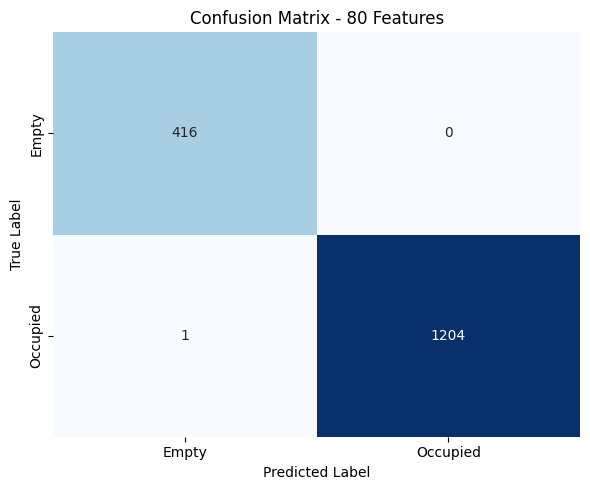

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Stratified Split to maintain the 25/75 class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_master, y_master, test_size=0.2, random_state=42, stratify=y_master
)

print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Testing shapes:  X={X_test.shape}, y={y_test.shape}")

# 2. Initialize LightGBM with balanced weights for the minority class
# We keep n_estimators relatively low to simulate a lightweight edge model
lgb_clf = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 # Use all available CPU cores for training
)

# 3. Train the model
print("\n⚙️ Training LightGBM Model...")
lgb_clf.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred = lgb_clf.predict(X_test)

print("\n============================================================")
print("🏆 BASELINE LIGHTGBM RESULTS (80 Features) 🏆")
print("============================================================")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Empty (0)', 'Occupied (1)']))

# 5. Plot the Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Empty', 'Occupied'],
            yticklabels=['Empty', 'Occupied'])
plt.title('Confusion Matrix - 80 Features')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


⚙️ Running Top-Kt Optimization (Testing 1 to 20 features)...


c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: U

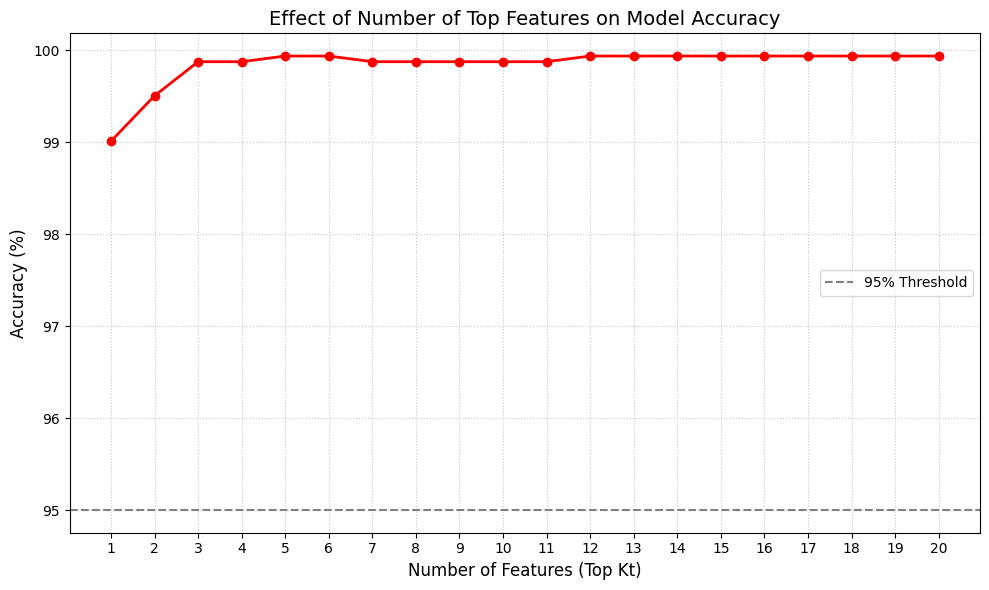

📉 DIMENSIONALITY REDUCTION REPORT 📉
Peak Accuracy: 99.94% achieved with 5 features.
Accuracy with just top 5 features: 99.94%


In [6]:
# 1. Extract feature importances from the baseline model
importances = lgb_clf.feature_importances_
# Get indices of features sorted by importance (highest first)
sorted_indices = np.argsort(importances)[::-1]

# We will test using 1 to 20 features
max_features_to_test = 20
k_values = list(range(1, max_features_to_test + 1))
accuracies = []

print(f"\n⚙️ Running Top-Kt Optimization (Testing 1 to {max_features_to_test} features)...")

for k in k_values:
    # Select the top K feature indices
    top_k_idx = sorted_indices[:k]
    
    # Train a lean model on just these K features
    lean_clf = lgb.LGBMClassifier(
        n_estimators=50, # Even lighter model
        learning_rate=0.1,
        class_weight='balanced',
        random_state=42,
        verbosity=-1
    )
    
    # Fit and score
    lean_clf.fit(X_train[:, top_k_idx], y_train)
    acc = lean_clf.score(X_test[:, top_k_idx], y_test)
    accuracies.append(acc)

# 2. Plot the optimization curve (Matches Fig 10 in the IEEE paper!)
plt.figure(figsize=(10, 6))
plt.plot(k_values, [a * 100 for a in accuracies], marker='o', linestyle='-', color='red', linewidth=2)
plt.axhline(y=95.0, color='gray', linestyle='--', label='95% Threshold')

plt.title('Effect of Number of Top Features on Model Accuracy', fontsize=14)
plt.xlabel('Number of Features (Top Kt)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Output the optimal finding
best_k = np.argmax(accuracies) + 1
best_acc = np.max(accuracies) * 100
print("============================================================")
print("📉 DIMENSIONALITY REDUCTION REPORT 📉")
print("============================================================")
print(f"Peak Accuracy: {best_acc:.2f}% achieved with {best_k} features.")
print(f"Accuracy with just top 5 features: {accuracies[4] * 100:.2f}%")

# Correcting things a bit

In [23]:
import os
import glob
import numpy as np

def build_master_dataset_with_groups(directory_path, active_indices):
    print("🚀 Starting Group-Aware Master Pipeline...")
    mat_files = glob.glob(os.path.join(directory_path, '*.mat'))
    
    X_list, y_list, group_list = [], [], []
    file_count = 0
    
    for file_path in mat_files:
        filename = os.path.basename(file_path)
        label = 0 if filename.upper().startswith('E') else 1
        
        try:
            first_level = extract_first_level_features(file_path, active_indices)
            second_level = extract_second_level_features(first_level)
            
            X_list.append(second_level)
            y_list.extend([label] * second_level.shape[0])
            
            # TRACKING THE LEAKAGE: Tag every window with its source file ID
            group_list.extend([file_count] * second_level.shape[0])
            file_count += 1
            
        except Exception as e:
            print(f"❌ Failed to process {filename}: {e}")
            
    X_final = np.vstack(X_list)
    y_final = np.array(y_list)
    groups_final = np.array(group_list)
    
    return X_final, y_final, groups_final

# Run the updated pipeline
X_master, y_master, groups_master = build_master_dataset_with_groups('processed_files', active_subcarriers)

print("\n============================================================")
print("🏆 GROUP-AWARE DATASET COMPILED 🏆")
print(f"Matrix (X): {X_master.shape} | Labels (y): {y_master.shape} | Groups: {groups_master.shape}")
print("============================================================")

🚀 Starting Group-Aware Master Pipeline...
Extracting features from processed_files\E1.mat...
Applying Second-Level Feature Window (N_F=8)...
Extracting features from processed_files\E2.mat...
Applying Second-Level Feature Window (N_F=8)...
Extracting features from processed_files\E3.mat...
Applying Second-Level Feature Window (N_F=8)...
Extracting features from processed_files\E4.mat...
Applying Second-Level Feature Window (N_F=8)...
Extracting features from processed_files\R1_P1.mat...
Applying Second-Level Feature Window (N_F=8)...
Extracting features from processed_files\R2_P1.mat...
Applying Second-Level Feature Window (N_F=8)...
Extracting features from processed_files\R3_P1.mat...
Applying Second-Level Feature Window (N_F=8)...
Extracting features from processed_files\R4_P1.mat...
Applying Second-Level Feature Window (N_F=8)...
Extracting features from processed_files\S1_P1.mat...
Applying Second-Level Feature Window (N_F=8)...
Extracting features from processed_files\S2_P1.mat..

In [24]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, accuracy_score
import lightgbm as lgb
import matplotlib.pyplot as plt

# 1. Leak-Proof Split
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_master, y_master, groups_master))

X_train, X_test = X_master[train_idx], X_master[test_idx]
y_train, y_test = y_master[train_idx], y_master[test_idx]

print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Testing shapes:  X={X_test.shape}, y={y_test.shape}")

# 2. Train LightGBM
lgb_clf = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\n⚙️ Training Leak-Proof LightGBM Model...")
lgb_clf.fit(X_train, y_train)

# 3. Predict and Evaluate
y_pred = lgb_clf.predict(X_test)

print("\n============================================================")
print("🏆 TRUE REAL-WORLD LIGHTGBM RESULTS 🏆")
print("============================================================")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Empty (0)', 'Occupied (1)']))

Training shapes: X=(4535, 80), y=(4535,)
Testing shapes:  X=(1516, 80), y=(1516,)

⚙️ Training Leak-Proof LightGBM Model...

🏆 TRUE REAL-WORLD LIGHTGBM RESULTS 🏆
Overall Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

   Empty (0)       1.00      1.00      1.00       773
Occupied (1)       1.00      1.00      1.00       743

    accuracy                           1.00      1516
   macro avg       1.00      1.00      1.00      1516
weighted avg       1.00      1.00      1.00      1516



c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



⚙️ Running True Real-World Top-Kt Optimization (Testing 1 to 20 features)...


c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: U

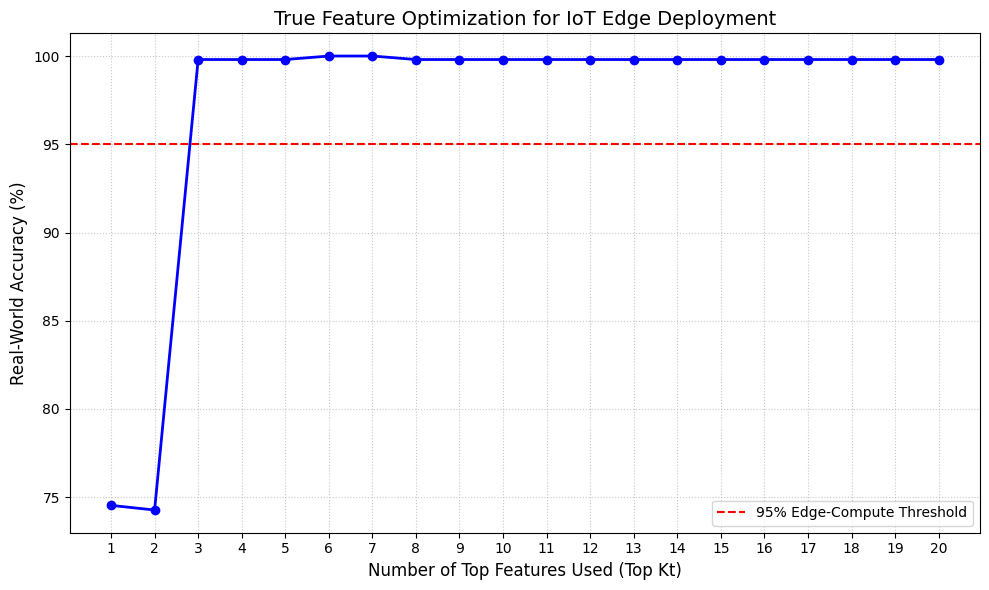

📉 IOT EDGE OPTIMIZATION REPORT 📉
Peak Accuracy: 100.00% achieved with 6 features.
Accuracy with just top 3 features: 99.80%
Accuracy with just top 5 features: 99.80%


In [25]:
# 1. Extract feature importances from our Leak-Proof model
importances = lgb_clf.feature_importances_
# Get indices of features sorted by importance (highest first)
sorted_indices = np.argsort(importances)[::-1]

# We will test using 1 to 20 features
max_features_to_test = 20
k_values = list(range(1, max_features_to_test + 1))
accuracies = []

print(f"\n⚙️ Running True Real-World Top-Kt Optimization (Testing 1 to {max_features_to_test} features)...")

for k in k_values:
    # Select the top K feature indices
    top_k_idx = sorted_indices[:k]
    
    # Train a lean edge-model on just these K features
    lean_clf = lgb.LGBMClassifier(
        n_estimators=50, # Lighter model for edge compute
        learning_rate=0.1,
        class_weight='balanced',
        random_state=42,
        verbosity=-1
    )
    
    # Fit and score using the LEAK-PROOF splits
    lean_clf.fit(X_train[:, top_k_idx], y_train)
    y_pred_lean = lean_clf.predict(X_test[:, top_k_idx])
    acc = accuracy_score(y_test, y_pred_lean)
    accuracies.append(acc)

# 2. Plot the optimization curve 
plt.figure(figsize=(10, 6))
plt.plot(k_values, [a * 100 for a in accuracies], marker='o', linestyle='-', color='blue', linewidth=2)
plt.axhline(y=95.0, color='red', linestyle='--', label='95% Edge-Compute Threshold')

plt.title('True Feature Optimization for IoT Edge Deployment', fontsize=14)
plt.xlabel('Number of Top Features Used (Top Kt)', fontsize=12)
plt.ylabel('Real-World Accuracy (%)', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Output the optimal finding
best_k = np.argmax(accuracies) + 1
best_acc = np.max(accuracies) * 100
print("============================================================")
print("📉 IOT EDGE OPTIMIZATION REPORT 📉")
print("============================================================")
print(f"Peak Accuracy: {best_acc:.2f}% achieved with {best_k} features.")
print(f"Accuracy with just top 3 features: {accuracies[2] * 100:.2f}%")
print(f"Accuracy with just top 5 features: {accuracies[4] * 100:.2f}%")

In [26]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd

# 1. Define the search space for the "Smart Router" constraints
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5],             # Shallow trees for edge compute
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],       # Prevent overfitting
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [3.0]           # Handling 25/75 imbalance (3:1 ratio)
}

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# 2. Use Randomized Search with GroupKFold to maintain our Leak-Proof split
from sklearn.model_selection import GroupKFold
gkf = GroupKFold(n_splits=3)

print("⚙️ Tuning XGBoost Hyperparameters (Leak-Proof)...")
random_search = RandomizedSearchCV(
    xgb_model, param_distributions=param_dist, 
    n_iter=10, cv=gkf, scoring='f1_weighted', n_jobs=-1, random_state=42
)

# We use the full master dataset because CV handles the splitting
#random_search.fit(X_master, y_master, groups=groups_master)
random_search.fit(X_train, y_train, groups=groups_master[train_idx])
best_xgb = random_search.best_estimator_

# 3. Final Evaluation on our held-out test set
y_pred_xgb = best_xgb.predict(X_test)

print("\n============================================================")
print("🏆 TUNED XGBOOST RESULTS (Leak-Proof) 🏆")
print("============================================================")
print(f"Best Params: {random_search.best_params_}")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Empty (0)', 'Occupied (1)']))

⚙️ Tuning XGBoost Hyperparameters (Leak-Proof)...

🏆 TUNED XGBOOST RESULTS (Leak-Proof) 🏆
Best Params: {'subsample': 0.7, 'scale_pos_weight': 3.0, 'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Overall Accuracy: 99.80%

Classification Report:
              precision    recall  f1-score   support

   Empty (0)       1.00      1.00      1.00       773
Occupied (1)       1.00      1.00      1.00       743

    accuracy                           1.00      1516
   macro avg       1.00      1.00      1.00      1516
weighted avg       1.00      1.00      1.00      1516



c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:56:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\shrey\AppData\Local\Temp\ipykernel_45232\2706744999.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis')



🚀 TOP 5 FEATURES FOR SMART ROUTER DEPLOYMENT 🚀
                         Feature  Importance
3           Ant0_Mean_Nakagami_m  239.671661
63          Ant3_Mean_Nakagami_m  131.657578
19  Ant0_Rician_K_Nakagami_Omega   25.320160
9        Ant0_STD_Nakagami_Omega   23.890926
50                  Ant2_PAR_avg   15.953431


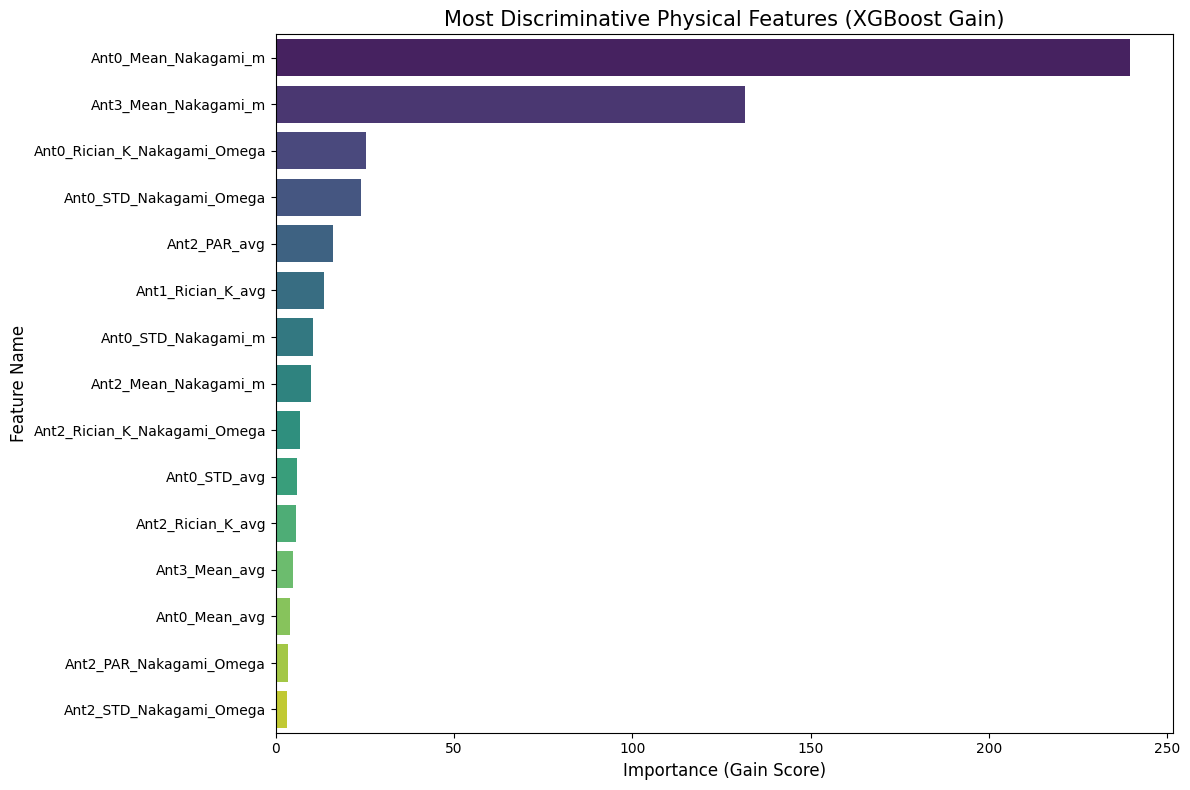

In [27]:
import seaborn as sns
# 1. Get feature importance from the tuned XGBoost model
# We'll use 'gain' as it shows which features contribute most to the accuracy
importance_scores = best_xgb.get_booster().get_score(importance_type='gain')

# 2. Map indices to names for the presentation
# Feature order was: [base_mean, lcr, afd, m, omega] for each of the 16 original stats
stat_names = ['Mean', 'STD', 'PAR', 'Rician_K']
antenna_names = ['Ant0', 'Ant1', 'Ant2', 'Ant3']
base_feature_names = []
for ant in antenna_names:
    for stat in stat_names:
        base_feature_names.append(f"{ant}_{stat}")

final_names = []
for base in base_feature_names:
    for sub_stat in ['_avg', '_LCR', '_AFD', '_Nakagami_m', '_Nakagami_Omega']:
        final_names.append(base + sub_stat)

# 3. Create a DataFrame for easy viewing
feat_imp_df = pd.DataFrame({
    'Feature': final_names,
    'Importance': [importance_scores.get(f'f{i}', 0) for i in range(80)]
}).sort_values(by='Importance', ascending=False)

print("\n============================================================")
print("🚀 TOP 5 FEATURES FOR SMART ROUTER DEPLOYMENT 🚀")
print("============================================================")
print(feat_imp_df.head(5))

# 4. Plot the top 15 for your SIH Presentation slides
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis')
plt.title('Most Discriminative Physical Features (XGBoost Gain)', fontsize=15)
plt.xlabel('Importance (Gain Score)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

In [28]:
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np

print("============================================================")
print("🛡️ RUNNING THE RUTHLESS SANITY CHECKS 🛡️")
print("============================================================")

# --- THE STRATIFIED GROUP SPLIT ---
sgkf = StratifiedGroupKFold(n_splits=4)
# Get just the first split
train_idx, test_idx = next(sgkf.split(X_master, y_master, groups_master))

X_train, X_test = X_master[train_idx], X_master[test_idx]
y_train, y_test = y_master[train_idx], y_master[test_idx]

print(f"\n[Check 1] Train Groups (Files): {np.unique(groups_master[train_idx])}")
print(f"[Check 1] Test Groups (Files): {np.unique(groups_master[test_idx])}")

print(f"\n[Check 4] Test Set Class Balance:")
print(f"  - Empty (0): {np.sum(y_test == 0)}")
print(f"  - Occupied (1): {np.sum(y_test == 1)}")

# --- RETRAIN THE MODEL PROPERLY ---
lgb_real = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, class_weight='balanced', random_state=42, verbosity=-1)
lgb_real.fit(X_train, y_train)
real_acc = lgb_real.score(X_test, y_test)
print(f"\n✅ True Stratified-Group Accuracy: {real_acc * 100:.2f}%")

# --- CHECK 3: THE PERMUTATION TEST ---
print("\n☢️ INITIATING PERMUTATION TEST (SHUFFLING LABELS) ☢️")
# We shuffle the training labels to destroy the physical relationship
y_train_shuffled = np.random.permutation(y_train)

lgb_fake = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, class_weight='balanced', random_state=42, verbosity=-1)
lgb_fake.fit(X_train, y_train_shuffled)
fake_acc = lgb_fake.score(X_test, y_test)

print(f"❌ Permutation Accuracy (Should be near 50% or majority class guess): {fake_acc * 100:.2f}%")
print("============================================================")

🛡️ RUNNING THE RUTHLESS SANITY CHECKS 🛡️

[Check 1] Train Groups (Files): [ 0  1  3  4  5  6  8  9 10 11 12 13]
[Check 1] Test Groups (Files): [ 2  7 14 15]

[Check 4] Test Set Class Balance:
  - Empty (0): 390
  - Occupied (1): 1121

✅ True Stratified-Group Accuracy: 99.14%

☢️ INITIATING PERMUTATION TEST (SHUFFLING LABELS) ☢️
❌ Permutation Accuracy (Should be near 50% or majority class guess): 58.77%


c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
